In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from collections import namedtuple
from matplotlib.ticker import MultipleLocator
from scipy.optimize import curve_fit

In [2]:
# data for Japan 2020-2024
values_male = [
    0.097, 0.105, 0.112, 0.124, 0.13 , 0.144, 0.161, 0.178, 0.198, 0.218,
    0.241, 0.271, 0.295, 0.327, 0.365, 0.397, 0.439, 0.483, 0.524, 0.578,
    0.632, 0.703, 0.774, 0.855, 0.939, 1.034, 1.138, 1.258, 1.383, 1.55 ,
    1.706, 1.891, 2.086, 2.288, 2.536, 2.815, 3.091, 3.38 , 3.761, 4.2  ,
    4.669, 5.221, 5.809, 6.521, 7.324, 8.286, 9.334, 10.558, 11.859, 13.34, 14.943]

values_female = [
    0.059, 0.063, 0.068, 0.073, 0.082, 0.088, 0.096, 0.107, 0.117, 0.131,
    0.144, 0.158, 0.17 , 0.184, 0.197, 0.208, 0.225, 0.239, 0.25 , 0.273,
    0.293, 0.311, 0.345, 0.368, 0.405, 0.439, 0.466, 0.518, 0.571, 0.628,
    0.694, 0.765, 0.855, 0.951, 1.062, 1.205, 1.34 , 1.493, 1.707, 1.943,
    2.239, 2.545, 2.941, 3.37 , 3.893, 4.548, 5.215, 6.058, 7.042, 8.112, 9.455]

In [3]:
# data for Canada 2017-2019
# values_male = [
#     0.145, 0.154, 0.164, 0.175, 0.188, 0.201, 0.216, 0.233, 0.251, 0.272,
#     0.295, 0.321, 0.349, 0.379, 0.413, 0.45 , 0.491, 0.536, 0.585, 0.64 ,
#     0.7  , 0.766, 0.839, 0.92 , 1.009, 1.108, 1.217, 1.339, 1.473, 1.622,
#     1.787, 1.971, 2.175, 2.402, 2.655, 2.937, 3.25 , 3.6  , 3.991, 4.428,
#     4.916, 5.461, 6.072, 6.756, 7.522, 8.382, 9.347, 10.431, 11.65, 13.02, 14.562]

# values_female = [
#      0.079, 0.086, 0.095, 0.103, 0.113, 0.123, 0.134, 0.146, 0.159, 0.172,
#      0.187, 0.203, 0.22, 0.239, 0.26, 0.284, 0.309, 0.338, 0.369, 0.404,
#      0.442, 0.485, 0.532, 0.585, 0.643, 0.708, 0.78, 0.861, 0.951, 1.051,
#      1.164, 1.289, 1.43, 1.588, 1.765, 1.964, 2.187, 2.439, 2.722, 3.041,
#      3.402, 3.809, 4.27, 4.791, 5.382, 6.052, 6.812, 7.676, 8.659, 9.778, 11.054]

In [4]:
# data for the USA 2015-2019
# values_male = [
#     0.247, 0.255, 0.266, 0.281, 0.303, 0.327, 0.355, 0.381, 0.412, 0.45,
#     0.493, 0.542, 0.594, 0.647, 0.715, 0.781, 0.84, 0.917, 0.983, 1.066,
#     1.14 , 1.234, 1.324, 1.427, 1.512, 1.609, 1.704, 1.805, 1.936, 2.073,
#     2.235, 2.438, 2.662, 2.864, 3.17 , 3.47 , 3.779, 4.121, 4.481, 4.957,
#     5.617, 6.247, 6.922, 7.67 , 8.557, 9.466, 10.565, 11.793, 13.129, 14.58, 16.17]

# values_female = [
#     0.141, 0.148, 0.16 , 0.172, 0.184, 0.203, 0.222, 0.236, 0.26 , 0.282,
#     0.31 , 0.34 , 0.37 , 0.402, 0.438, 0.475, 0.516, 0.558, 0.598, 0.639,
#     0.689, 0.736, 0.791, 0.847, 0.906, 0.969, 1.04 , 1.128, 1.24 , 1.347,
#     1.483, 1.625, 1.818, 1.967, 2.181, 2.417, 2.642, 2.909, 3.217, 3.586,
#     4.143, 4.629, 5.225, 5.834, 6.501, 7.279, 8.15 , 9.154, 10.239, 11.475, 12.904]

In [5]:
values_years = range(40, 91)

df = pd.DataFrame(data = [values_male, values_female],
                  index = ['male', 'female'],
                  columns = values_years)

df

,40,41,42,43,44,45,46,47,48,49,...,81,82,83,84,85,86,87,88,89,90
male,0.097,0.105,0.112,0.124,0.130,0.144,0.161,0.178,0.198,0.218,...,5.221,5.809,6.521,7.324,8.286,9.334,10.558,11.859,13.340,14.943
female,0.059,0.063,0.068,0.073,0.082,0.088,0.096,0.107,0.117,0.131,...,2.545,2.941,3.370,3.893,4.548,5.215,6.058,7.042,8.112,9.455


In [7]:
DisplayedGroup = namedtuple('DisplayedGroup', ['name', 'color', 'style', 'width'])

dd_display = {
    'male'  : DisplayedGroup(name="male",   color='blue', style='-', width=5),
    'female': DisplayedGroup(name="female", color='red',  style='-', width=5)
}

In [8]:
# simple Gompertz function
def gompertz(age, amplitude, coef):
    return amplitude * np.exp(coef * age)
    
# Gompertz function with permanent Makeham component
def gompertz_makeham(age, amplitude, coef, makeham_component):
    return amplitude * np.exp(coef * age) + makeham_component  # makeham_component - permanent external mortality

<br>

Estimated parameters: [0.000431   0.11597354 0.14389577]
First 5 estimated values: [0.19 0.19 0.2  0.21 0.21]

Estimated parameters: [1.58302787e-05 1.47516902e-01 1.45408054e-01]
First 5 estimated values: [0.15 0.15 0.15 0.15 0.16]



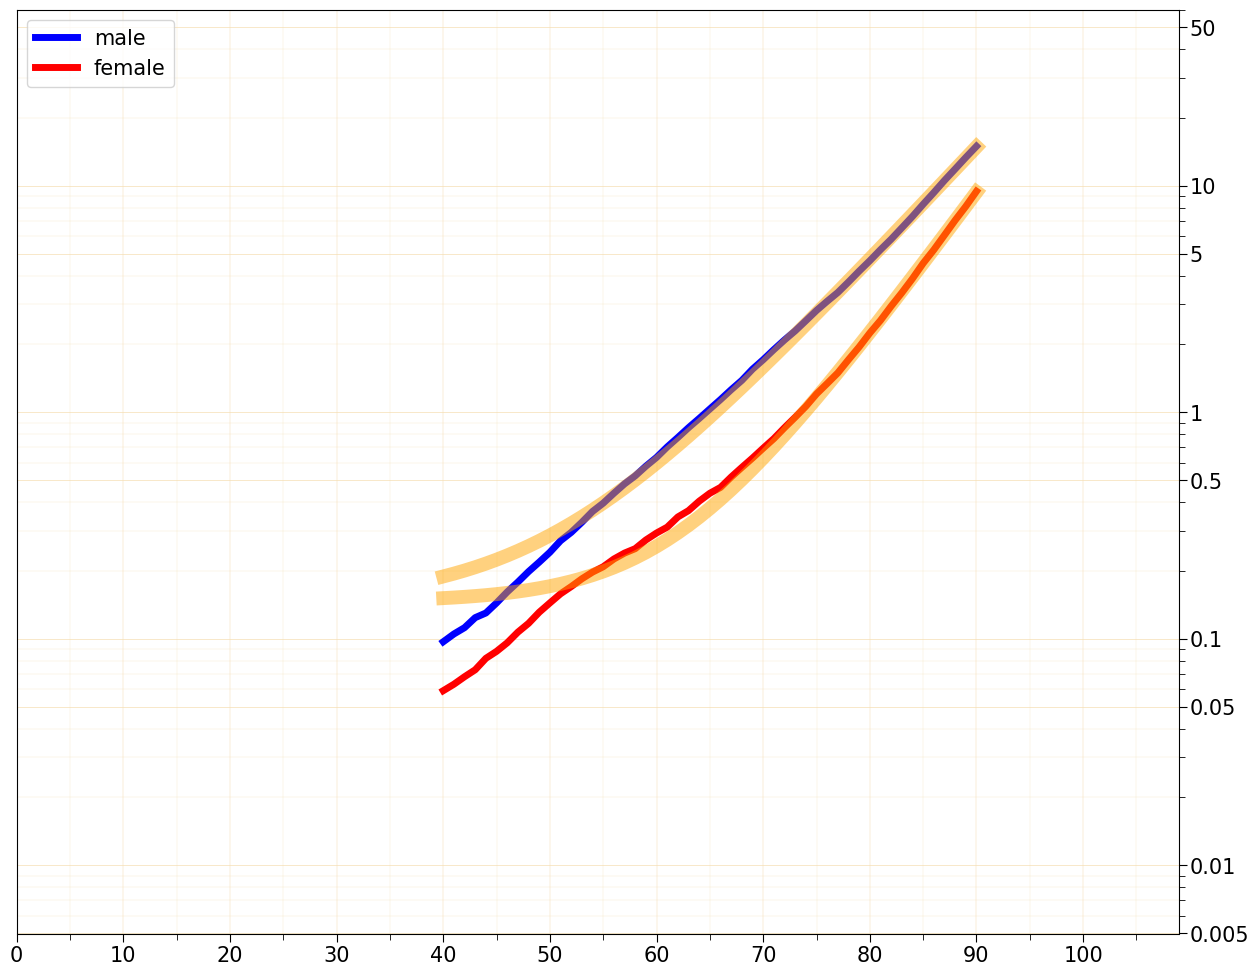

In [10]:
#1. Selecting coefficients using curve_fit, simple
def create_chart_log(df):
    plt.rcParams['figure.figsize'] = (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.set_yscale('log')       # Make Y-axis logarithmic  # alternative: plt.yscale('log')
    
    ax.yaxis.tick_right()      # show ticks only at the left side
    ax.yaxis.set_label_position('right')  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=6, pad=3)   # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=4)          # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=6, pad=1.5) # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=4)          # Minor ticks are shorter
    plt.xticks(fontsize=15)                                    # font size for tick labels
    labels_y = [0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
    plt.yticks(ticks=labels_y, labels=labels_y, fontsize=15)
    
    x_min = y_min = 0
    x_max = 109
    y_max = 60
    plt.xlim(0, 109)
    plt.ylim(0.005, 60)

    plt.grid(which='major', axis='x', color='wheat', linewidth=0.35)
    plt.grid(which='major', axis='y', color='wheat', linewidth=0.5)
    plt.grid(which='minor', color='wheat', linewidth=0.20)

    # segment of ages (including endpoints) where aproximation is searched
    range_start = 40
    range_end = 90

    # Generate x-values for the considered interval
    x = np.linspace(range_start, range_end, range_end-range_start+1)

    # Code that creates approximated y-values and draws charts for male and female separately
    for group in ['male', 'female']:
        y_originals = df.loc[group, x].values
        coefs, _ = curve_fit(gompertz_makeham, x, y_originals, p0=[1e-4, 0.10, 0.0005])  #maxfev = 100_000
        print("Estimated parameters:", coefs)
        y_approximated = gompertz_makeham(x, *coefs)
        print("First 5 estimated values:", y_approximated[:5].round(2))
        plt.plot(x, y_approximated, color='orange', linewidth=10, alpha=0.5, zorder=101)
        print()
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=dd_display[gr].name, zorder=100-i)

    plt.legend(loc='upper left', fontsize=15)

    plt.show()


create_chart_log(df)

<br>

Estimated parameters: [0.00075965 0.10944183 0.05384437]
First 5 estimated values: [0.11 0.12 0.13 0.14 0.15]

Estimated parameters: [4.19060305e-05 1.36307794e-01 8.79282190e-02]
First 5 estimated values: [0.1 0.1 0.1 0.1 0.1]



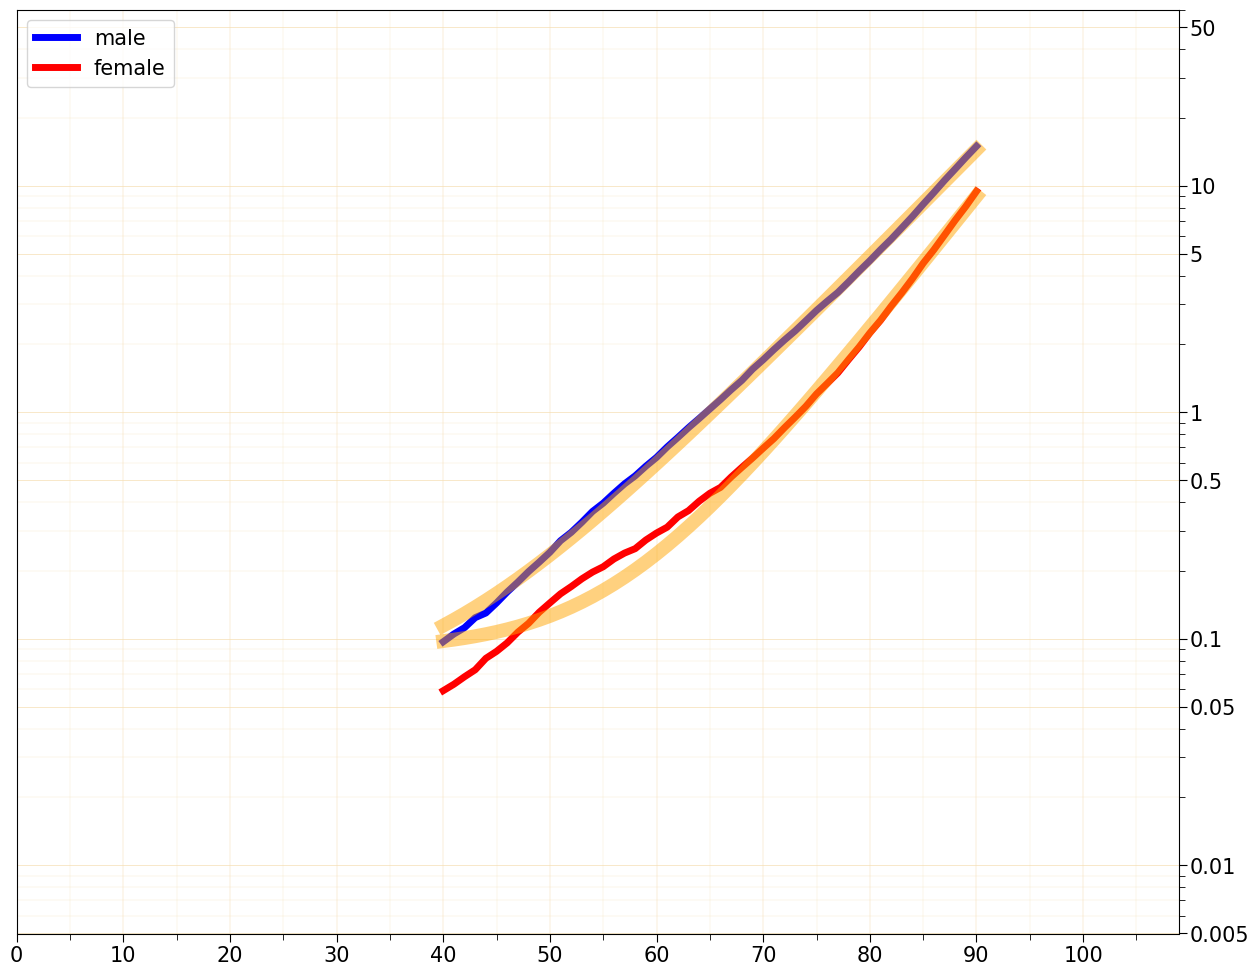

In [12]:
#2. Selecting coefficients using curve_fit, when the point weight is inversely proportional to the value
def create_chart_log_weights(df):
    plt.rcParams['figure.figsize'] = (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.set_yscale('log')       # Make Y-axis logarithmic  # alternative: plt.yscale('log')
    
    ax.yaxis.tick_right()      # show ticks only at the left side
    ax.yaxis.set_label_position('right')  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=6, pad=3)   # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=4)          # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=6, pad=1.5) # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=4)          # Minor ticks are shorter
    plt.xticks(fontsize=15)                                    # font size for tick labels
    labels_y = [0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
    plt.yticks(ticks=labels_y, labels=labels_y, fontsize=15)
    
    x_min = y_min = 0
    x_max = 109
    y_max = 60
    plt.xlim(0, 109)
    plt.ylim(0.005, 60)

    plt.grid(which='major', axis='x', color='wheat', linewidth=0.35)
    plt.grid(which='major', axis='y', color='wheat', linewidth=0.5)
    plt.grid(which='minor', color='wheat', linewidth=0.20)

    # segment of ages (including endpoints) where aproximation is searched
    range_start = 40
    range_end = 90

    # Generate x-values for the considered interval
    x = np.linspace(range_start, range_end, range_end-range_start+1)

    # Code that creates approximated y-values and draws charts for male and female separately
    for group in ['male', 'female']:
        y_originals = df.loc[group, x].values
        sigma = np.sqrt(y_originals)  # point weight is inversely proportional to the value, w ~ 1 / y
        # sigma = y_originals         # point weight is inversely proportional to the square of the value, w ~ 1 / y²
        coefs, _ = curve_fit(gompertz_makeham, x, y_originals, p0=[1e-4, 0.10, 0.0005],
                             sigma=sigma, absolute_sigma=False)  #maxfev = 100_000
        print("Estimated parameters:", coefs)
        y_approximated = gompertz_makeham(x, *coefs)
        print("First 5 estimated values:", y_approximated[:5].round(2))
        plt.plot(x, y_approximated, color='orange', linewidth=10, alpha=0.5, zorder=101)
        print()
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=dd_display[gr].name, zorder=100-i)

    plt.legend(loc='upper left', fontsize=15)

    plt.show()


create_chart_log_weights(df)

<br>

In [14]:
def calculate_increase_rate_and_doubling_period(age1: int, age2: int, v1: float, v2: float):
    '''
    This function calculate two characteristics of a geometric progression (in the context of aging)
    - by what percentage does the value increase every year (in percent)
    - period of doubling (in years)
    '''
    q = math.pow((v2 / v1),
                  1 / (age2 - age1))  # find 'common ratio' of the geometric progression
                                      # (age2 - age1) √ (v2 / v1)      – (age2-age1)th root of (v2 / v1)

    T = math.log(2, q)  # doubling period:    log base 'q' of 2
    return (q - 1) * 100, T

Model: y = 0.001602 * exp(0.100136 * x)
Coefficient of determination (R²): {r2:.6f}
annual increase: 10.532 %,   doubling period:  6.922 years

Model: y = 0.001014 * exp(0.096615 * x)
Coefficient of determination (R²): {r2:.6f}
annual increase: 10.144 %,   doubling period:  7.174 years



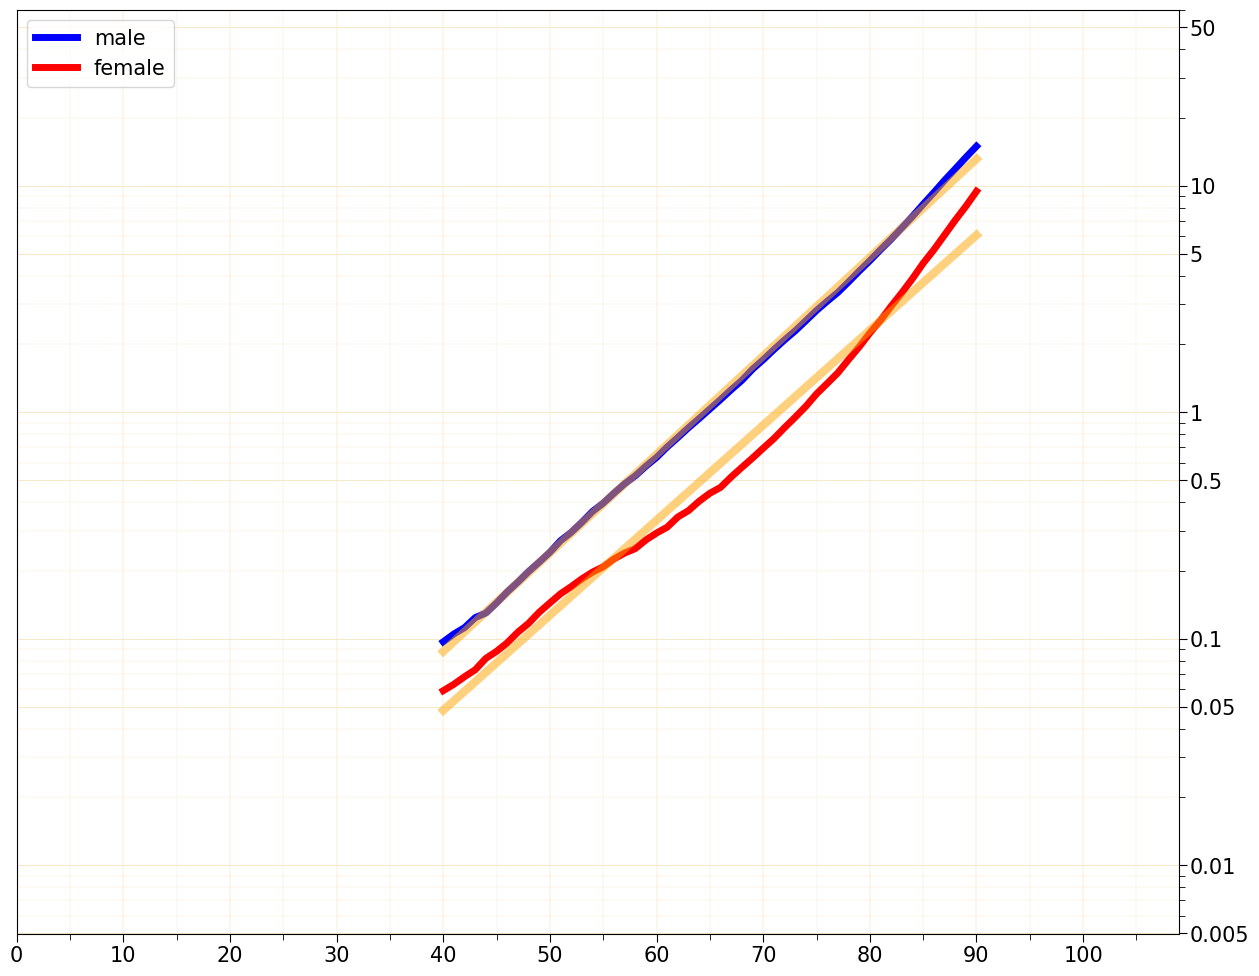

In [15]:
#3 Alternative approach, with linear regression on logarithms.
# This approach minimizes errors in logarithms
#    unlike the method of the least squares used in 'curve_fit'.
def create_chart_log_linear_regression_logarithms(df):
    plt.rcParams['figure.figsize'] = (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.set_yscale('log')       # Make Y-axis logarithmic  # alternative: plt.yscale('log')
    
    ax.yaxis.tick_right()      # show ticks only at the left side
    ax.yaxis.set_label_position('right')  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=6, pad=3)   # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=4)          # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=6, pad=1.5) # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=4)          # Minor ticks are shorter
    plt.xticks(fontsize=15)                                    # font size for tick labels
    labels_y = [0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
    plt.yticks(ticks=labels_y, labels=labels_y, fontsize=15)
    
    x_min = y_min = 0
    x_max = 109
    y_max = 60
    plt.xlim(0, 109)
    plt.ylim(0.005, 60)

    plt.grid(which='major', axis='x', color='wheat', linewidth=0.35)
    plt.grid(which='major', axis='y', color='wheat', linewidth=0.5)
    plt.grid(which='minor', color='wheat', linewidth=0.20)

    # segment of ages (including endpoints) where aproximation is searched
    range_start = 40
    range_end = 90

    # Generate x-values for the considered interval
    x = np.linspace(range_start, range_end, range_end-range_start+1)

    for group in ['male', 'female']:
        y = df.loc[group, x].values             # take the y values
        ln_y = np.log(y)                        # take the logarithm of the y values
        b, ln_a = np.polyfit(x, ln_y, deg=1)    # do linear regression
                                                #    b - slope of the line
                                                #    b - intersection of the 'ln a' with the y-axis
        a = np.exp(ln_a)                        # recover the amplitude of the exponent
        print(f"Model: y = {a:.6f} * exp({b:.6f} * x)")

        y_fit = a * np.exp(b * x)               # approximated function
        plt.plot(x, y_fit, color='orange', linewidth=6, alpha=0.5, zorder=101)  # plot the estimation for male/female

        ss_res = np.sum((y - y_fit) ** 2)       # calculate the coefficient of determination
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - ss_res / ss_tot
        print("Coefficient of determination (R²): {r2:.6f}")

        rate_perc, period_double = calculate_increase_rate_and_doubling_period(x[0], x[-1], y_fit[0], y_fit[-1])
        print(f"annual increase: {rate_perc:6.3f} %,   doubling period: {period_double:6.3f} years")
        print()

    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=dd_display[gr].name, zorder=100-i)

    plt.legend(loc='upper left', fontsize=15)

    plt.show()


create_chart_log_linear_regression_logarithms(df)

<br>

In [17]:
# # Clean function - without code for approximation
# def create_chart_log(df):
#     plt.rcParams['figure.figsize'] = (15, 12)
    
#     fig, ax = plt.subplots()   # Create a figure and axis
#     ax.set_yscale('log')       # Make Y-axis logarithmic  # alternative: plt.yscale('log')
    
#     ax.yaxis.tick_right()      # show ticks only at the left side
#     ax.yaxis.set_label_position('right')  # set the label position to the right 

#     ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
#     ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5

#     # Customize tick lengths
#     ax.tick_params(axis='x', which='major', length=6, pad=3)   # Major ticks are longer
#     ax.tick_params(axis='x', which='minor', length=4)          # Minor ticks are shorter
#     ax.tick_params(axis='y', which='major', length=6, pad=1.5) # Major ticks are longer
#     ax.tick_params(axis='y', which='minor', length=4)          # Minor ticks are shorter
#     plt.xticks(fontsize=15)                                    # font size for tick labels
#     labels_y = [0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
#     plt.yticks(ticks=labels_y, labels=labels_y, fontsize=15)
    
#     x_min = y_min = 0
#     x_max = 109
#     y_max = 60
#     plt.xlim(0, 109)
#     plt.ylim(0.005, 60)

#     plt.grid(which='major', axis='x', color='wheat', linewidth=0.35)
#     plt.grid(which='major', axis='y', color='wheat', linewidth=0.5)
#     plt.grid(which='minor', color='wheat', linewidth=0.20)
    
#     for i, gr in enumerate(df.index.to_list()):
#         ser = df.loc[gr]
#         plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
#                  linewidth=dd_display[gr].width, label=dd_display[gr].name, zorder=100-i)

#     plt.legend(loc='upper left', fontsize=15)

#     plt.show()


# create_chart_log(df)

In [18]:
# # Version of the chart creation function for linear scale
# def create_chart(df):
#     plt.rcParams['figure.figsize'] = (15, 12)
    
#     fig, ax = plt.subplots()   # Create a figure and axis
#     ax.yaxis.tick_right()      # show ticks only at the left side
#     ax.yaxis.set_label_position('right')  # set the label position to the right 

#     ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
#     ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
#     ax.yaxis.set_major_locator(MultipleLocator(10))
#     ax.yaxis.set_minor_locator(MultipleLocator(5))

#     # Customize tick lengths
#     ax.tick_params(axis='x', which='major', length=6, pad=3)    # Major ticks are longer
#     ax.tick_params(axis='x', which='minor', length=4)           # Minor ticks are shorter
#     ax.tick_params(axis='y', which='major', length=6, pad=1.5)  # Major ticks are longer
#     ax.tick_params(axis='y', which='minor', length=4)           # Minor ticks are shorter
#     plt.xticks(fontsize=15)  # font size for tick labels
#     plt.yticks(fontsize=15)
    
#     x_min = y_min = 0
#     x_max = 109
#     y_max = 55
#     plt.xlim(0, 109)
#     plt.ylim(-1, 55)

#     plt.grid(which='major', color='wheat', linewidth=0.35)
#     plt.grid(which='minor', color='wheat', linewidth=0.20)

#     plt.axhline(y=0, color='wheat', linewidth=2)
    
#     for i, gr in enumerate(df.index.to_list()):
#         ser = df.loc[gr]
#         line_name = dd_display[gr].name
#         plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
#                  linewidth=dd_display[gr].width, label=line_name, zorder=100-i)

#     plt.legend(loc='upper left', fontsize=15)

#     plt.show()


# create_chart(df)

<br>

In [20]:
# This code allows to extract values for male & female from working scripts:
# values_male = df.loc[40:90, 'male'].round(3).tolist()
# print(values_male)

# values_female = df.loc[40:90, 'female'].round(3).tolist()
# print(values_female)